In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from utils import quality_metrics

# Allow more columns to be displayed
pd.set_option("display.max_columns", None)

import logging
logging.basicConfig(level=logging.WARNING)

In [3]:
!which python

/Users/klemenkubelj/miniconda3/envs/cvar-masters/bin/python


In [4]:
df = pd.read_excel(os.path.join("../data/predicted_flood_depths.xlsx"))
df = df[
    df["measured_depth"]<4
]
# Replace 0 values with 0.01 for all measured_depth
# df["measured_depth"] = df["measured_depth"].replace(0, 0.01)

In [5]:
df.shape

(5485, 14)

In [6]:
_df = df.copy()
_df["measured_depth"] = _df["measured_depth"].replace(0, 0.01)
quality_metrics.get_metrics(_df["measured_depth"], _df["predicted_si"])

{'within_5': 0.046308113035551504,
 'within_10': 0.059070191431175936,
 'within_15': 0.06964448495897903,
 'within_20': 0.10027347310847767,
 'overshoot_20': 0.2058340929808569,
 'median_relative_error': -0.75,
 'median_absolute_relative_error': 1.0,
 'st_dev_residuals': 7.019067056830569,
 'total_samples': 5485}

In [7]:
_df = df.copy()
quality_metrics.get_metrics(_df["measured_depth"], _df["predicted_si"])

{'within_5': 0.047766636280765724,
 'within_10': 0.060528714676390157,
 'within_15': 0.07110300820419325,
 'within_20': 0.10173199635369189,
 'overshoot_20': 0.20510483135824978,
 'median_relative_error': -0.75,
 'median_absolute_relative_error': 1.0,
 'st_dev_residuals': 6.62724360051476,
 'total_samples': 5485}

In [8]:
quality_metrics.get_metrics(df["measured_depth"], df["predicted_wri"])

{'within_5': 0.007110300820419325,
 'within_10': 0.007110300820419325,
 'within_15': 0.008021877848678213,
 'within_20': 0.019872379216043755,
 'overshoot_20': 0.03992707383773929,
 'median_relative_error': -1.0,
 'median_absolute_relative_error': 1.0,
 'st_dev_residuals': 2.062453332744097,
 'total_samples': 5485}

<Axes: xlabel='measured_depth', ylabel='predicted_si'>

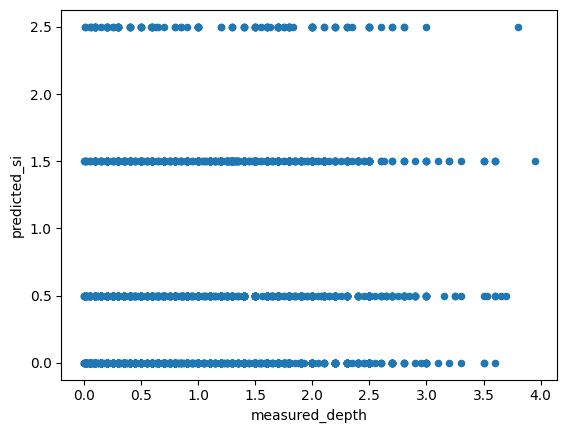

In [9]:
df.plot(x="measured_depth", y="predicted_si", kind="scatter")
# Plot x=y line
# plt.plot([0, 10], [0, 10], color="black")

<Axes: xlabel='measured_depth', ylabel='predicted_wri'>

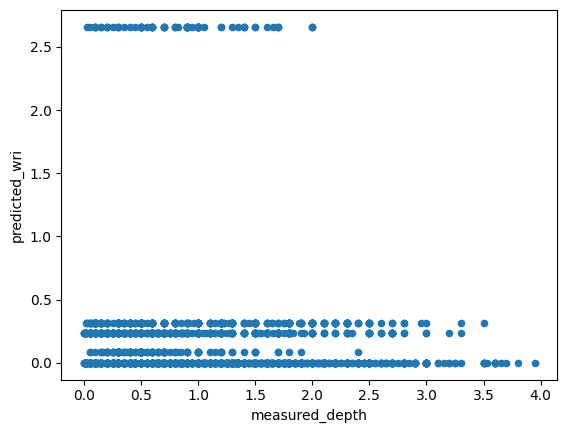

In [10]:
df.plot(x="measured_depth", y="predicted_wri", kind="scatter")

# Categorize measured_depth into 4 categories


In [11]:
df["depth_category"] = pd.cut(df["measured_depth"], bins=[0, 0.5, 1.5, 2.5], labels=[0.5, 1.5, 2.5])
# df.shape
# df.head()
# df.groupby("depth_category").mean()
# df.groupby("depth_category").mean()

In [12]:
df["depth_category"].value_counts()

depth_category
1.5    2420
0.5    2053
2.5     892
Name: count, dtype: int64

<Axes: xlabel='depth_category', ylabel='predicted_si'>

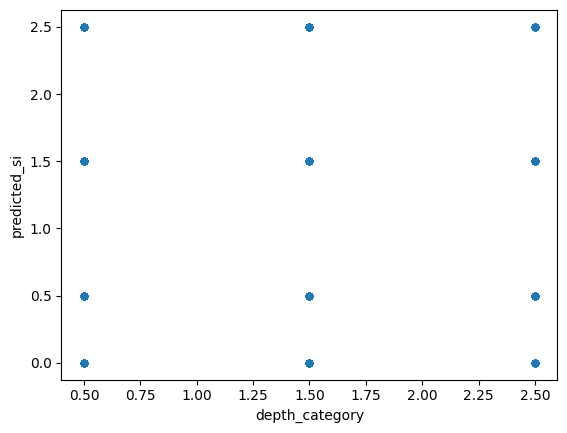

In [13]:
df.plot(x="depth_category", y="predicted_si", kind="scatter")

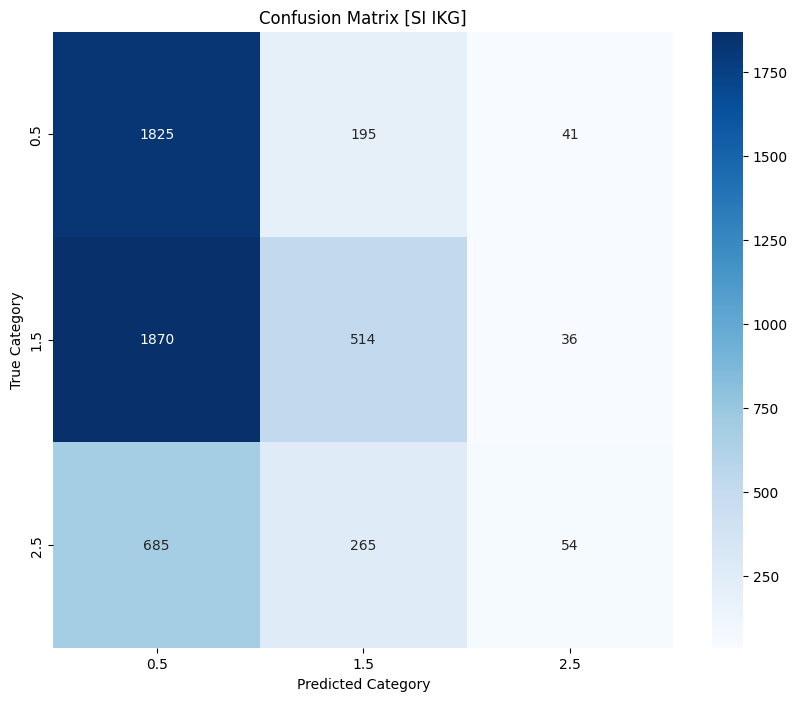

In [20]:
# First, let's bin the measured_depth into categories and do the same for predictions
from sklearn.metrics import confusion_matrix
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Create categorical bins for the depths
def categorize_depth(depth):
    if depth <= 0.5:
        return "0.5"
    elif depth <= 1.5:
        return "1.5"
    return "2.5"

# Create the categorical labels
_df = df.copy()
_df["depth_category_true"] = _df["measured_depth"].apply(categorize_depth)
_df["depth_category_pred"] = _df["predicted_si"].apply(categorize_depth)

# Calculate confusion matrix
cm = confusion_matrix(_df["depth_category_true"], _df["depth_category_pred"])
categories = ["0.5", "1.5", "2.5"]

# Plot the confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", 
            xticklabels=categories, 
            yticklabels=categories)
plt.title("Confusion Matrix [SI IKG]")
plt.xlabel("Predicted Category")
plt.ylabel("True Category")
plt.show()

In [21]:
# TODO: Calculate:
# - Classification accuracy
# - Precision
# - Recall
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

# Calculate all metrics
accuracy = accuracy_score(_df["depth_category_true"], _df["depth_category_pred"])
precision, recall, f1, support = precision_recall_fscore_support(
    _df["depth_category_true"], 
    _df["depth_category_pred"],
    labels=["0.5", "1.5", "2.5"],
    average=None
)

# Create a nice summary dataframe
import pandas as pd

metrics_df = pd.DataFrame({
    "Category": ["0.5", "1.5", "2.5"],
    "Precision": precision,
    "Recall": recall,
    "Support": support
})

# Print overall accuracy
print(f"Overall Classification Accuracy: {accuracy:.3f}\n")

# Print per-category metrics
print("Per-category metrics:")
print(metrics_df.to_string(index=False))

"""
Metrics explanation:
- Accuracy: Proportion of correct predictions among total predictions
- Precision: Proportion of correct positive predictions among all positive predictions for each category
- Recall: Proportion of correct positive predictions among all actual positives for each category
- Support: Number of samples in each category
"""

Overall Classification Accuracy: 0.436

Per-category metrics:
Category  Precision   Recall  Support
     0.5   0.416667 0.885492     2061
     1.5   0.527721 0.212397     2420
     2.5   0.412214 0.053785     1004


'\nMetrics explanation:\n- Accuracy: Proportion of correct predictions among total predictions\n- Precision: Proportion of correct positive predictions among all positive predictions for each category\n- Recall: Proportion of correct positive predictions among all actual positives for each category\n- Support: Number of samples in each category\n'

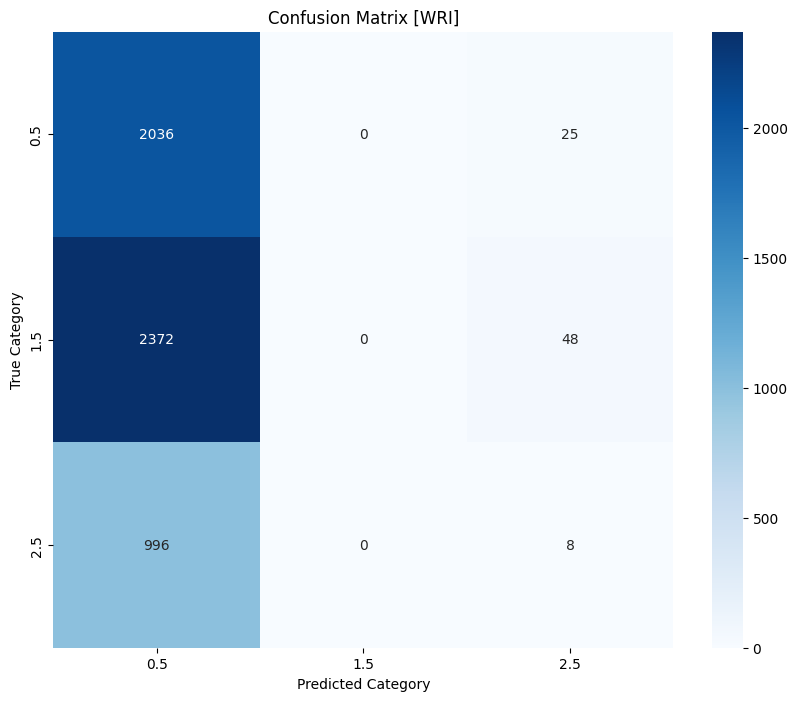

In [22]:
# First, let's bin the measured_depth into categories and do the same for predictions
from sklearn.metrics import confusion_matrix
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Create categorical bins for the depths
def categorize_depth(depth):
    if depth <= 0.5:
        return "0.5"
    elif depth <= 1.5:
        return "1.5"
    return "2.5"

# Create the categorical labels
_df = df.copy()
_df["depth_category_true"] = _df["measured_depth"].apply(categorize_depth)
_df["depth_category_pred"] = _df["predicted_wri"].apply(categorize_depth)

# Calculate confusion matrix
cm = confusion_matrix(_df["depth_category_true"], _df["depth_category_pred"])
categories = ["0.5", "1.5", "2.5"]

# Plot the confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", 
            xticklabels=categories, 
            yticklabels=categories)
plt.title("Confusion Matrix [WRI]")
plt.xlabel("Predicted Category")
plt.ylabel("True Category")
plt.show()

In [23]:
# TODO: Calculate:
# - Classification accuracy
# - Precision
# - Recall
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

# Calculate all metrics
accuracy = accuracy_score(_df["depth_category_true"], _df["depth_category_pred"])
precision, recall, f1, support = precision_recall_fscore_support(
    _df["depth_category_true"], 
    _df["depth_category_pred"],
    labels=["0.5", "1.5", "2.5"],
    average=None
)

# Create a nice summary dataframe
import pandas as pd

metrics_df = pd.DataFrame({
    "Category": ["0.5", "1.5", "2.5"],
    "Precision": precision,
    "Recall": recall,
    "Support": support
})

# Print overall accuracy
print(f"Overall Classification Accuracy: {accuracy:.3f}\n")

# Print per-category metrics
print("Per-category metrics:")
print(metrics_df.to_string(index=False))

"""
Metrics explanation:
- Accuracy: Proportion of correct predictions among total predictions
- Precision: Proportion of correct positive predictions among all positive predictions for each category
- Recall: Proportion of correct positive predictions among all actual positives for each category
- Support: Number of samples in each category
"""

Overall Classification Accuracy: 0.373

Per-category metrics:
Category  Precision   Recall  Support
     0.5   0.376758 0.987870     2061
     1.5   0.000000 0.000000     2420
     2.5   0.098765 0.007968     1004


/Users/klemenkubelj/miniconda3/envs/cvar-masters/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


'\nMetrics explanation:\n- Accuracy: Proportion of correct predictions among total predictions\n- Precision: Proportion of correct positive predictions among all positive predictions for each category\n- Recall: Proportion of correct positive predictions among all actual positives for each category\n- Support: Number of samples in each category\n'